# Analytics Module
The Analytics module provides descriptive statistics on content data, evidence data and model evaluations 

In [15]:
# reloads modules automatically before entering the execution of code
%load_ext autoreload
%autoreload 2

# third parties imports
import numpy as np 
import pandas as pd
# -- add new imports here --

# local imports
from constants import Constant as C
from loaders import load_ratings
from loaders import load_items

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1 - Content analytics
Explore and perform descriptive statistics on content data

In [16]:
# -- load the items and display the Dataframe

print(C.CONTENT_PATH)
print(C.ITEMS_FILENAME)
print(C.CONTENT_PATH/C.ITEMS_FILENAME)

#df = pd.read_csv(C.CONTENT_PATH/C.ITEMS_FILENAME)
#print(df.head())

df_items = load_items()

#add the column movieID initially used as an index
df_items = df_items.reset_index()

display(df_items)

data\tiny\content
movies.csv
data\tiny\content\movies.csv


,movieId,title,genres
0,3,Grumpier Old Men (1995),Comedy|Romance
1,15,Cutthroat Island (1995),Action|Adventure|Romance
2,34,Babe (1995),Children|Drama
3,59,"Confessional, The (Confessionnal, Le) (1995)",Drama|Mystery
4,64,Two if by Sea (1996),Comedy|Romance
...,...,...,...
907,148652,The Ridiculous 6 (2015),Comedy|Western
908,151307,The Lovers and the Despot,(no genres listed)
909,152173,Michael Jackson's Thriller (1983),Horror
910,160440,The Maid's Room (2014),Thriller


In [17]:
# -- display relevant informations that can be extracted from the dataset

n_movies = df_items.shape[0]

print(f"Number of movies : {n_movies} ")

df_items['year'] = df_items[C.LABEL_COL].str.extract(r'\((\d{4})\)')

print(df_items.head())

Number of movies : 912 
   movieId                                         title  \
0        3                       Grumpier Old Men (1995)   
1       15                       Cutthroat Island (1995)   
2       34                                   Babe (1995)   
3       59  Confessional, The (Confessionnal, Le) (1995)   
4       64                          Two if by Sea (1996)   

                     genres  year  
0            Comedy|Romance  1995  
1  Action|Adventure|Romance  1995  
2            Children|Drama  1995  
3             Drama|Mystery  1995  
4            Comedy|Romance  1996  


# 2 - Evidence analytics
Explore and perform descriptive statistics on evidence data

In [ ]:
# -- load the items and display the Dataframe

df_ratings = load_ratings()

display(df_ratings)



,userId,movieId,rating,timestamp
0,15,34,3.0,997938310
1,15,95,1.5,1093028331
2,15,101,4.0,1134522072
3,15,123,4.0,997938358
4,15,125,3.5,1245362506
...,...,...,...,...
5291,665,3908,1.0,1046967201
5292,665,4052,4.0,992838277
5293,665,4351,4.0,992837743
5294,665,4643,4.0,997239207


In [ ]:
# -- display relevant informations that can be extracted from the dataset

nbr_rating = df_ratings.shape[0]
print(f"Total number of ratings :  {nbr_rating}") 

nbr_unique_user = len(df_ratings.loc[:,C.USER_ID_COL].unique())
print(f"Unique Number of users : {nbr_unique_user}")

nbr_unique_movies = len(df_ratings.loc[:,C.ITEM_ID_COL].unique())
print(f"Unique Number of movies : {nbr_unique_movies}")

max_rating = df_ratings[C.RATING_COL].max()

top_movies = df_ratings[df_ratings[C.RATING_COL]==max_rating]

#print(top_movies[[C.ITEM_ID_COL, C.RATING_COL]])
print(f"Number of most rated movie(s) : {len(top_movies)}")

#less_rated_movies

min_rating = df_ratings[C.RATING_COL].min()

less_movies = df_ratings[df_ratings[C.RATING_COL]==min_rating]

#print(less_movies[[C.ITEM_ID_COL, C.RATING_COL]])
print(f"Number of less rated movie(s) :  {len(less_movies)}")

#all_possible_rating_values_from smalles to highest value

rating_values = sorted(df_ratings[C.RATING_COL].unique())

print(f"Rating values in ascending order :\n {rating_values}")

movies_with_rating = df_ratings[C.ITEM_ID_COL].unique()

unspecified_movies = df_items[~df_items[C.ITEM_ID_COL].isin(movies_with_rating)]

print(f"Number of no rating movies : {len(unspecified_movies)}")


Total number of ratings :  5296
Unique Number of users : 107
Unique Number of movies : 834
Number of most rated movie(s) : 650
Number of less rated movie(s) :  64
Rating values in ascending order :
 [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
Number of no rating movies : 78


# 3 - Long-tail property

movieId
1240    75
1210    75
858     72
527     71
500     61
Name: count, dtype: int64
834
   movieId  frequency  rank
0     1240         75     1
1     1210         75     2
2      858         72     3
3      527         71     4
4      500         61     5


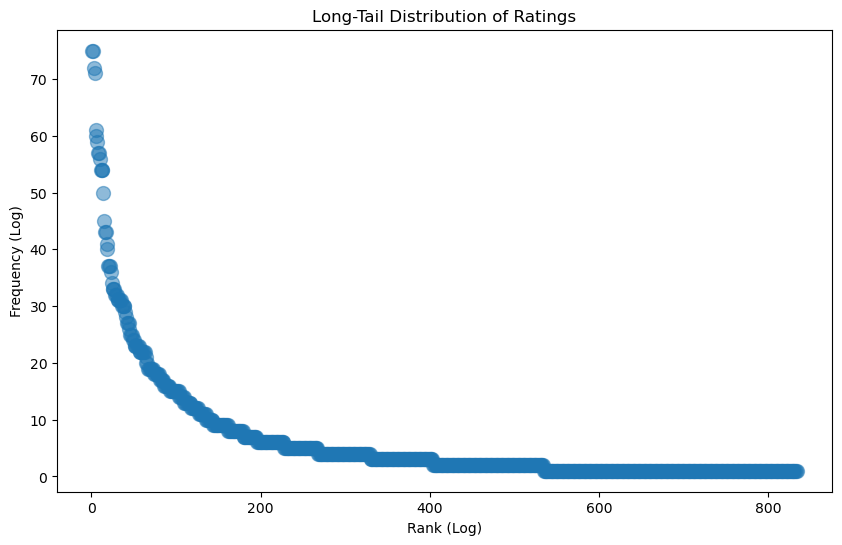

In [ ]:
import matplotlib.pyplot as plt

movies_counts = df_ratings[C.ITEM_ID_COL].value_counts().sort_values(ascending=False)

print(movies_counts.head())
print(movies_counts.shape[0])

movies_counts= movies_counts.reset_index()
movies_counts.columns = [C.ITEM_ID_COL, 'frequency']

movies_counts['rank'] = range(1,len(movies_counts)+1)

print(movies_counts.head())


plt.figure(figsize=(10,6))
plt.scatter(movies_counts['rank'], movies_counts['frequency'], s=100, alpha=0.5)

plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title('Long-Tail Distribution of Ratings')
plt.show()


# 4 - Sparsity

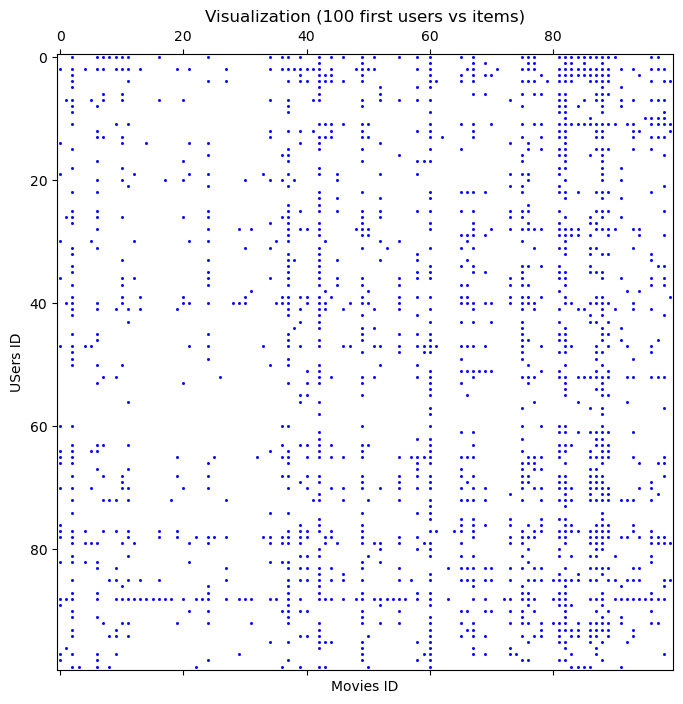

Number of ratings : 5296
Matrix dimension : 107 users x 834 movies
Sparsity : 94.07 %


In [ ]:

from scipy.sparse import csr_matrix

def create_X(df):
    """
    Generates a sparse matrix from ratings dataframe.

    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)

    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df[C.USER_ID_COL].nunique()
    N = df[C.ITEM_ID_COL].nunique()

    user_mapper = dict(zip(np.unique(df[C.USER_ID_COL]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df[C.ITEM_ID_COL]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df[C.USER_ID_COL])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df[C.ITEM_ID_COL])))

    user_index = [user_mapper[i] for i in df[C.USER_ID_COL]]
    item_index = [movie_mapper[i] for i in df[C.ITEM_ID_COL]]

    X = csr_matrix((df[C.RATING_COL], (user_index,item_index)), shape=(M,N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(df_ratings)

X_subset= X[:100,:100]

# 2. Display with .spy()
plt.figure(figsize=(8, 8))
plt.spy(X_subset, markersize=1, color='blue')

# Adding labels for clarity
plt.title("Visualization (100 first users vs items)")
plt.xlabel("Movies ID")
plt.ylabel("Users ID")

plt.show()

total_size = nbr_unique_user*nbr_unique_movies

sparsity = 1 - (nbr_rating/total_size)

print(f"Number of ratings : {nbr_rating}")
print(f"Matrix dimension : {nbr_unique_user} users x {nbr_unique_movies} movies")
print(f"Sparsity : {sparsity * 100:.2f} %")